### DATA:
HEART DISEASE DATASET

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

file_path = r"/content/drive/MyDrive/heart.csv"
data = pd.read_csv(file_path)
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


### Fase 1: Definicion del objetivo

### Objetivo:
¿Cuáles son los factores clínicos y demográficos (como la edad, el sexo, el colesterol y la frecuencia cardiaca) que permiten diferenciar a un paciente sano de uno con enfermedad cardiaca en la poblacion de estudio?

### Fase 3: Procesamiento y limpieza de datos:


### Fase 3.1: Revision inicial

In [ ]:
data.shape

(1025, 14)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [ ]:
data.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [ ]:
data.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


In [ ]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [ ]:
print(data.isna().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
print(data.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
print(data.duplicated())

0       False
1       False
2       False
3       False
4       False
        ...  
1020     True
1021     True
1022     True
1023     True
1024     True
Length: 1025, dtype: bool


In [ ]:
print(data.duplicated().sum())

723


In [ ]:
duplicados= data[data.duplicated()]
print(duplicados)

      age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
15     34    0   1       118   210    0        1      192      0      0.7   
31     50    0   1       120   244    0        1      162      0      1.1   
43     46    1   0       120   249    0        0      144      0      0.8   
55     55    1   0       140   217    0        1      111      1      5.6   
61     66    0   2       146   278    0        0      152      0      0.0   
...   ...  ...  ..       ...   ...  ...      ...      ...    ...      ...   
1020   59    1   1       140   221    0        1      164      1      0.0   
1021   60    1   0       125   258    0        0      141      1      2.8   
1022   47    1   0       110   275    0        0      118      1      1.0   
1023   50    0   0       110   254    0        0      159      0      0.0   
1024   54    1   0       120   188    0        1      113      0      1.4   

      slope  ca  thal  target  
15        2   0     2       1  
31        2

In [ ]:
data

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


Revision de consistencia de valores: Esta revisión sirve para asegurarnos de que los datos de los pacientes sean lógicos y reales antes de hacer las gráficas.


In [ ]:
print("Rango de edades:", data["age"].min(), "a", data["age"].max(), "años")
print("Rango de presion arterial:", data["trestbps"].min(), "a", data["trestbps"].max(), "mm Hg")
print("Rango de colesterol sérico:", data["chol"].min(), "a", data["chol"].max(), "mg/dL")
print("Rango de frecuencia cardíaca máxima:", data["thalach"].max(), "a", data["thalach"].min(), "BPM" )

Rango de edades: 29 a 77 años
Rango de presion arterial: 94 a 200 mm Hg
Rango de colesterol sérico: 126 a 564 mg/dL
Rango de frecuencia cardíaca máxima: 202 a 71 BPM


In [ ]:
print("Valores únicos en columnas categóricas")
print("Sexo (Esperado[0,1]):", data["sex"].unique())
print("Target (Esperado[0,1]):", data["target"].unique())
print("Tipo de dolor -cp (Esperado[0,1,2,3]):", data["cp"].unique())

Valores únicos en columnas categóricas
Sexo (Esperado[0,1]): [1 0]
Target (Esperado[0,1]): [0 1]
Tipo de dolor -cp (Esperado[0,1,2,3]): [0 1 2 3]


### Fase 3.2: Limpieza

### Nota de Limpieza (Fase 3.2):
- **Tratamiento de valores nulos:** Al ejecutar el comando `data.isnull().sum()`, se confirmó que el dataset contiene 0 valores nulos en todas sus columnas. Por lo tanto, no se requiere aplicar ninguna técnica de eliminación (`dropna()` ni el de imputación por media, mediana o moda `fillna()`).


In [ ]:
data_limpia= data.drop_duplicates()

In [ ]:
data_limpia.shape

(302, 14)

In [ ]:
data_limpia.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,302.00000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,0.682119,0.963576,131.602649,246.500000,0.149007,0.526490,149.569536,0.327815,1.043046,1.397351,0.718543,2.314570,0.543046
std,9.04797,0.466426,1.032044,17.563394,51.753489,0.356686,0.526027,22.903527,0.470196,1.161452,0.616274,1.006748,0.613026,0.498970
min,29.00000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.00000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.50000,1.000000,1.000000,130.000000,240.500000,0.000000,1.000000,152.500000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.00000,1.000000,2.000000,140.000000,274.750000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.00000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### Nota de Limpieza (Fase 3.2):
- **Corrección de tipos:** No se requiere, ya que `data.info()` demostró que todas las variables tienen el formato numérico correcto (`int64` y `float64`).
- **Normalización de texto:** No aplica, dado que el dataset no contiene variables cualitativas en formato de texto.

### Fase 3.3: Transformación y decisiones sobre columnas

### Eliminación de columnas

In [ ]:
# Eliminar la columna 'fbs' del dataset limpio
df_final = data_limpia.drop(columns=['fbs']).copy()

print(f"Dataset definitivo listo: {df_final.shape[1]} columnas.")

Dataset definitivo listo: 13 columnas.


### Variables derivadas:

In [ ]:
#Agrupo las edades en 3 categorias clínicas: Joven, Adulto y Adulto Mayor
df_final["grupo_edad"] = pd.cut(df_final["age"],
                                bins= [0, 45, 60, 100],
                                labels= ["Joven ( <45 )", "Adulto ( 45-60)", "Adulto Mayor ( >60 )"])

#Cuantos pacientes quedaron en cada grupo
print(df_final["grupo_edad"].value_counts())


grupo_edad
Adulto ( 45-60)         160
Adulto Mayor ( >60 )     79
Joven ( <45 )            63
Name: count, dtype: int64


### Fase 4: Análisis explorativo y visualizaciones

### Gráficas

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

### Histograma

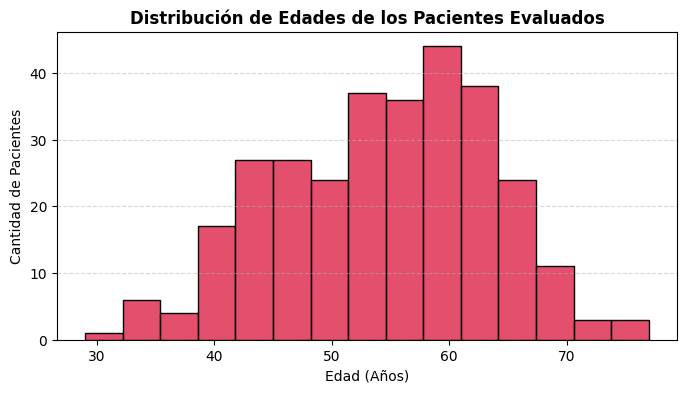

In [ ]:
plt.figure(figsize=(8, 4))
# Histograma de la columna 'age'
sns.histplot(data=df_final, x='age', color='crimson', bins=15)

plt.title('Distribución de Edades de los Pacientes Evaluados', fontsize=12, fontweight='bold')
plt.xlabel('Edad (Años)')
plt.ylabel('Cantidad de Pacientes')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Gráfica de barras

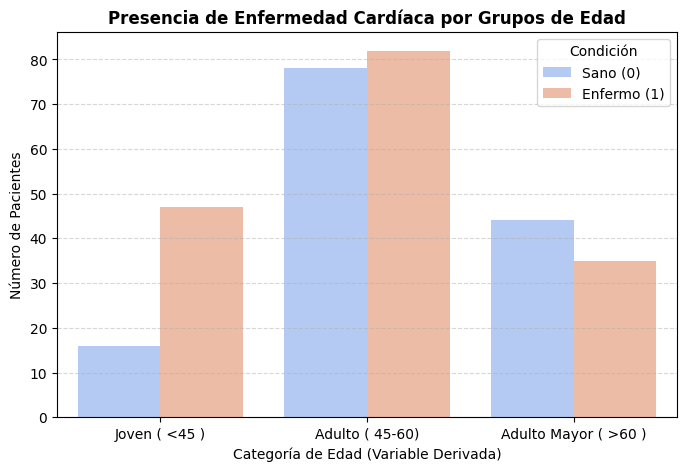

In [ ]:
plt.figure(figsize=(8, 5))
# Variable 'grupo_edad' con el diagnóstico ('target')
sns.countplot(data=df_final, x='grupo_edad', hue='target', palette='coolwarm')

plt.title('Presencia de Enfermedad Cardíaca por Grupos de Edad', fontsize=12, fontweight='bold')
plt.xlabel('Categoría de Edad (Variable Derivada)')
plt.ylabel('Número de Pacientes')
plt.legend(title='Condición', labels=['Sano (0)', 'Enfermo (1)'])
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Gráfica de dispersión

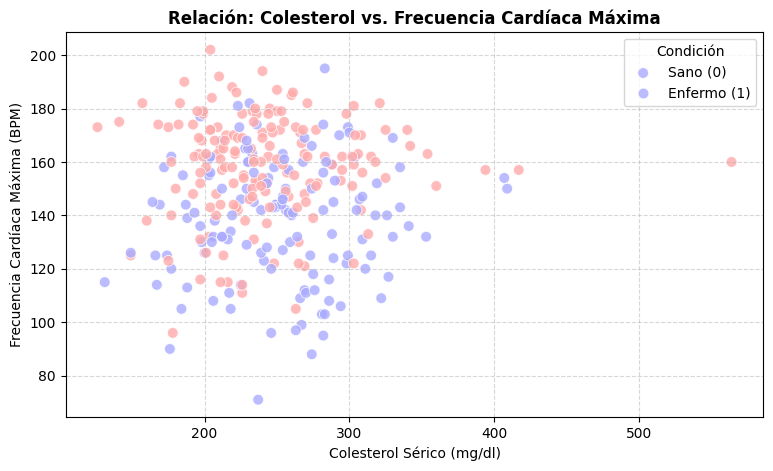

In [ ]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_final, x='chol', y='thalach', hue='target', palette='bwr', alpha=0.8, s=60)

plt.title('Relación: Colesterol vs. Frecuencia Cardíaca Máxima', fontsize=12, fontweight='bold')
plt.xlabel('Colesterol Sérico (mg/dl)', fontsize=10)
plt.ylabel('Frecuencia Cardíaca Máxima (BPM)', fontsize=10)
plt.legend(title='Condición', labels=['Sano (0)', 'Enfermo (1)'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Gráfico de pastel

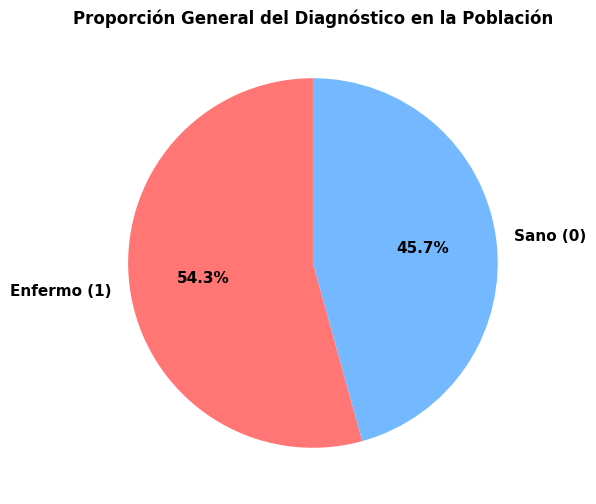

In [ ]:
plt.figure(figsize=(6, 6))

conteo_diagnostico = df_final['target'].value_counts()

plt.pie(conteo_diagnostico,
        labels=['Enfermo (1)', 'Sano (0)'],
        autopct='%1.1f%%',
        startangle=90,
        colors=['#ff7675', '#74b9ff'],
        textprops={'fontsize': 11, 'weight': 'bold'})

plt.title('Proporción General del Diagnóstico en la Población', fontsize=12, fontweight='bold')
plt.show()

### Boxplot

/tmp/ipykernel_14571/167969256.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_final, x='target', y='chol', palette='Set2', width=0.5)


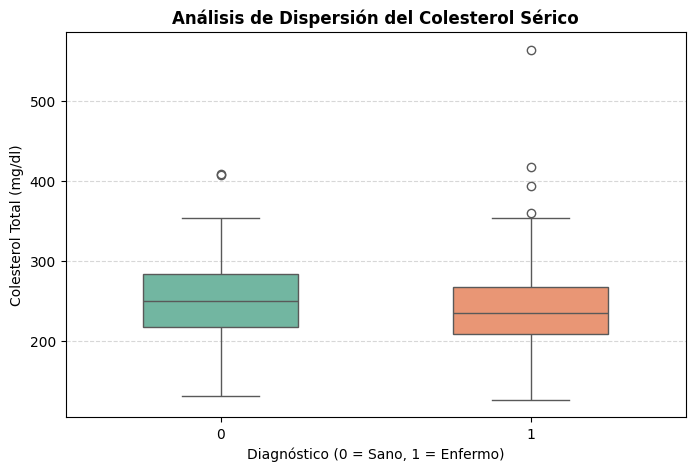

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_final, x='target', y='chol', palette='Set2', width=0.5)

plt.title('Análisis de Dispersión del Colesterol Sérico', fontsize=12, fontweight='bold')
plt.xlabel('Diagnóstico (0 = Sano, 1 = Enfermo)', fontsize=10)
plt.ylabel('Colesterol Total (mg/dl)', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### Mapa de calor

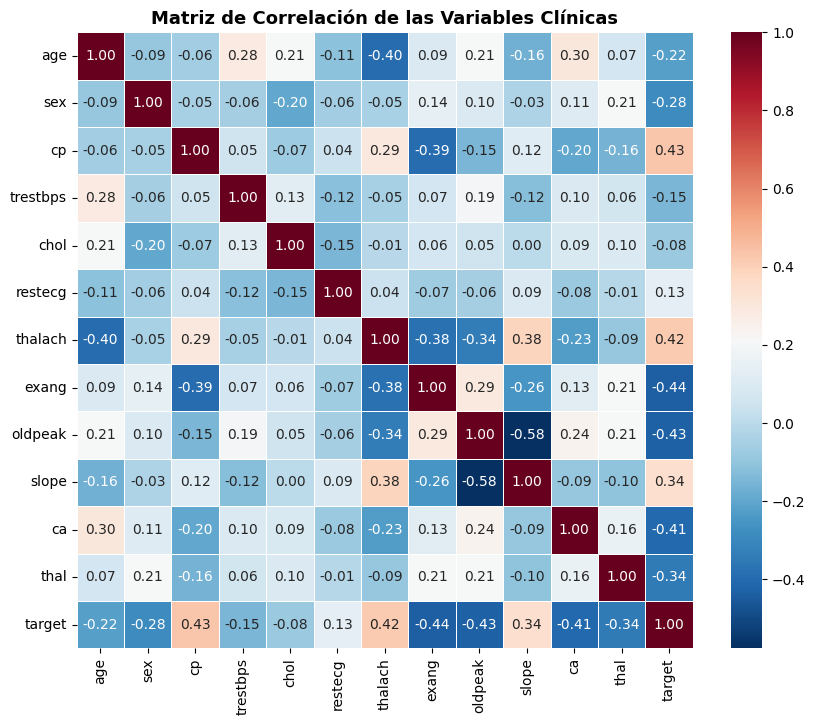

In [ ]:
plt.figure(figsize=(10, 8))
correlacion = df_final.corr(numeric_only=True)

sns.heatmap(correlacion, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5, square=True)

plt.title('Matriz de Correlación de las Variables Clínicas', fontsize=13, fontweight='bold')
plt.show()